# Exercise 4: Dimensionality Reduction

* Get a collection of 5 to 10 images of at least [512,512] pixels to do dimensionality reduction. 
* You can use photos from your family, friends, pets, etc.
* Use PCA/SVD in Go or in Julia.
* You will get bonus points if you do it in both, Go and Julia
* If you submit in Julia and in Go, do so as separated submissions with the following names:
    * Exercise4JL
    * Exercise4GO
* Submit your project following the submission guidelines


In [1]:
import Pkg; 
# Pkg.add("FileIO")

using Images
using LinearAlgebra
# using FileIO

Pkg.offline(true)

# Imagen 1

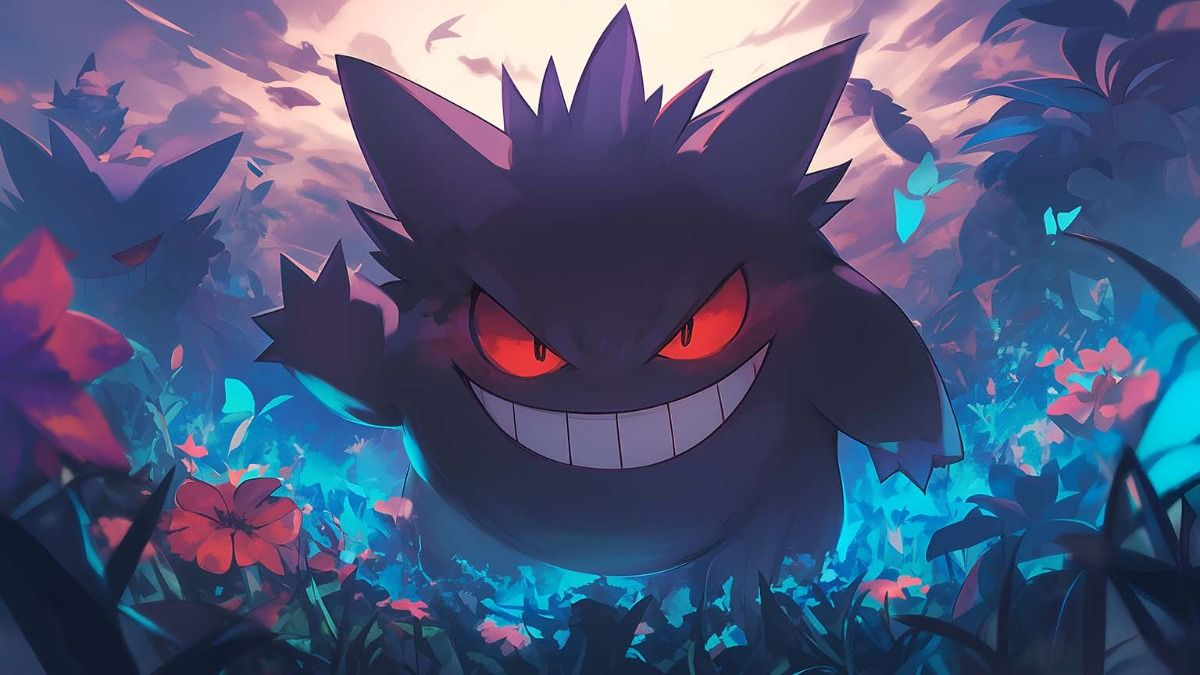

In [2]:
img = Images.load("./img/gengar.jpg")

In [31]:
img_matrix = channelview(img)
@show size(img_matrix)
println(img_matrix[:,1:5, 1:5])
#Tomando el canal 2 de RGB
img_matrix_red = img_matrix[2,:, :]
@time U, S, V = svd(img_matrix_red)
@show size(U)
@show size(S)
@show size(V)

(1200, 675)

In [ ]:
# @time s_vector = Diagonal(S)  # Extraer los valores diagonales de S
# @time s_vector = diagm(S)  # Extraer los valores diagonales de S
s_vector=copy(S)
# @show s_vector
# @show s_vector
norm_s_vector = s_vector / norm(s_vector)
@show norm_s_vector


# println("Vector de valores singulares:")
# println(size(s_vector))
# @show s_vector

675-element Vector{Float32}:
 0.91183203
 0.26359108
 0.15090784
 0.1174511
 0.08931086
 0.078773074
 0.06482515
 0.061359335
 0.05349385
 0.05020104
 ⋮
 7.2514944f-5
 7.196855f-5
 7.047301f-5
 6.87127f-5
 6.696251f-5
 6.5288645f-5
 6.3425134f-5
 6.168396f-5
 5.946911f-5

In [45]:
k = 50  # Puedes ajustar k según la precisión deseada
S_k = Diagonal(S[1:k])
println(size(S_k))
approx_img_matrix = U[:, 1:k] * S_k * V[:, 1:k]'
println(size(approx_img_matrix))
approx_img = Gray.(approx_img_matrix)
println(size(approx_img))
save("./img/imagen_aproximada.jpg", approx_img)
# img2 = Images.load("./img/imagen_aproximada.jpg")
# display(img2)

128387